<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D1%8D%D1%84%D1%84%D0%B5%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D1%8B%D0%B5_%D0%B2%D1%8B%D1%87%D0%B8%D1%81%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Эффективные вычисления

**Ключевые слова:** мантисса, интерпретатор, компилятор, распараллеливание

**План лекции:**
1. Способы представления чисел
2. Выполнение программ
3. Распараллеливание

Работа с данными не ограничивается математическими и алгоритмическими аспектами. Большое влияние на практическую работу в сфере обработки данных и искусственного интеллекта оказывает понимание и умение эффективно работать с вычислениями. В сегодняшней лекции мы поговорим о том, как устроены вычисления на реальных компьютерах, какие способы представления данных существуют, а также обсудим важную концепцию распараллеливания вычислений.

## Представление чисел в памяти компьютера

### Память

Память компьютера - это система устройств, которое используется для хранения данных и программ. Она состоит из нескольких типов памяти, каждый из которых выполняет определенные функции.

Кэш-память - это небольшая, но очень быстрая память, которая используется для временного хранения данных, к которым процессор обращается часто. Кэш-память помогает ускорить работу компьютера, уменьшая время доступа к данным.

Оперативная память (**RAM**) - это основная память компьютера, в которой хранятся данные, с которыми в данный момент работает процессор. Оперативная память имеет быстрый доступ к данным, но при выключении компьютера все данные в ней удаляются.

Жесткий диск (**HDD**) - это устройство для долгосрочного хранения данных. Жесткий диск имеет большую емкость, но доступ к данным на нем медленнее, чем к данным в оперативной памяти.



**С точки зрения практики программирования** важно понимать, как устроено взаимодействие памяти компьютера с переменными и командами, обработка которых представляет из себя нашу программу. Модельно можно представлять себе память компьютера как набор ячеек, в которые мы можем специальными аппаратными методами записывать (или извлекать) данные. Современные компьютеры устроены так, что каждая ячейка хранит одно из двух состояний - **0** или **1**. У каждой ячейки есть свой **адрес**, по которому мы можем обратиться к ней и прочитать, что в этой ячейке содержится.

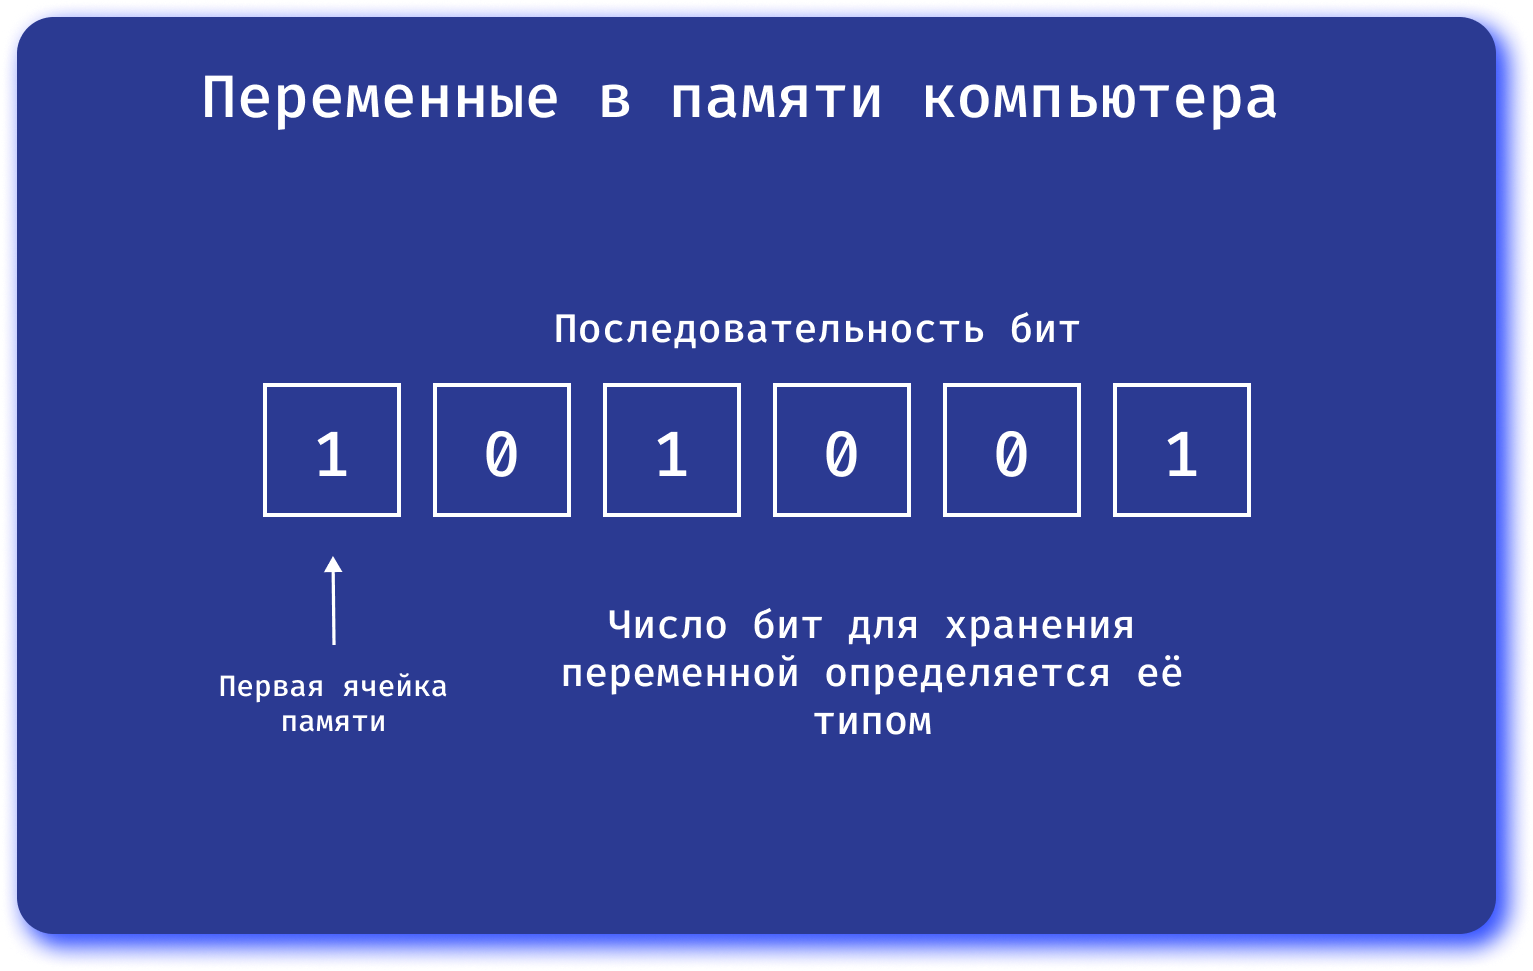

### Числовые типы данных

Как вы знаете, в математике выделяют разные типы чисел: натуральные, целые, рациональные, вещественные, комплексные. В программировании существует похожее деление. В отличие от фундаментальной математики, это деление вызвано необходимостью технической реализации вычислительных систем. Оказывается, что в зависимости от того, какие числа мы собираемся использовать для решения той или иной задачи, подходы к их представлению в памяти компьютера  используются разные. Мы разберём основные типы численных переменных.

#### 1. Целые числа

Достаточно просто в памяти компьютера представляются целые числа. Как вы знаете, одни и те же числа можно записывать в разных **системах счисления**. Мы все привыкли работать с **десятичной системой**, но в вычислительной технике обычно пользуются **двоичной и шестнадцатеричной** системами счисления. Как перевести число из десятично системы в двоичную?

Для этого нужно представить число $N$ в виде суммы степеней двойки:

$$N = a_02^0 + a_12^1 + a_22^2 + ...$$

Тут коэффициенты $a_0, a_1 ...$ могут принимать значения либо $0$, либо $1$.Последовательность этих коэффициентов от большего индекса к меньшему и даст нам искомое двоичное число. Например, если мы возьмем число $N = 6$ в десятичной системе, то оно разложится по степеням двойки следующим образом:

$$6_{10} = 0\cdot 2^0 + 1⋅2^1 + 1⋅2^2 + 0 + 0 + ...$$

Тогда двоичным кодом числа $6$ будет $6_{10} = [a_2, a_1, a_0]_2 = 110_2$

Обратим внимание на то, что для кодирования разных чисел нам может понадобиться разное число бит. Например, для кодирования числа $6$ нам понадобилось 3 бита, для кодирования числа $2$ - понадобится 2 бита, а для кодирования числа $128$ - понадобится уже 8 бит. Это говорит о том, что **если мы заранее определимся**, какое количество бит $k$ нам понадобится для кодирования целых чисел, у нас появится фундаментальное ограничение - мы сможем закодировать всего $2^k$ разных значений. С целью избежать проблем на практике, число $k$ обычно выбирают достаточно большим.

В `python` есть функция `bit_length`, которая позволяет определить, сколько бит требуется для хранения того или иного значения.

In [ ]:
(100000000).bit_length()

27

Таким образом, для хранения целых чисел нам нужна последовательность **бит**, в которых будут храниться **0** и **1**, представляющие из себя **двоичный код** целого числа. Выделяют знаковые и беззнаковые целые числа. Если мы предполагаем, что наше число не может быть меньше $0$, то мы можем записывать его напрямую в виде двоичного кода, а иначе нам потребуется выделить 1 бит под хранение знака числа. Единица в этом случае обозначает отрицательное число, а ноль - положительное.

#### Шестнадцатеричная система счисления

Очень часто в компьютерных науках используют **шестнадцатеричную систему счисления**. Эта система строится аналогично любой другой, но по основанию $16$. То есть число из десятичной системы переводится в шестнадцатеричную разложением этого числа по степеням $16$. Здесь возникает следующая проблема: цифра в любой системе счисления - это некоторая структурная единица, принимающая все возможные значения вплоть до основания этой системы. То есть в двоичной системе цифрами являются **0** и **1**, а числа, больше **1** - представляются комбинациями цифр, отображающих разложение этого числа через соответствующие степени двойки. Та же ситуация с десятичной: в ней существуют цифры от **0** до **9** (то есть все вплоть до основания системы **10**), что позволяет раскладывать произвольное число по степеням **10**. А значит, в любой системе счисления с основанием больше **10** должны существовать **цифры** больше 9, из которых будут складываться числа. Однако, нельзя использовать стандартные обозначения : **10**, **11**, **12** и т.д., поскольку **10** - само по себе является числом в шестнадцатеричной системе:
$$10_{16} = 16⋅1 + 1⋅0 = 16_{10}$$

А значит, "цифры, которые идут после **9**" надо как-то обозначить. Обычно их обозначают буквами латинского алфавита:

$$A_{16} → 10_{10}$$
$$B_{16} → 11_{10}$$
$$C_{16} → 12_{10}$$
$$D_{16} → 13_{10}$$
$$E_{16} → 14_{10}$$
$$F_{16} → 15_{10}$$

По этой причине, числа в 16-системе могут выглядеть странно. Например, число **26** выглядит так:
$$26_{10} = 1\cdot16 + A = 1A_{16}$$

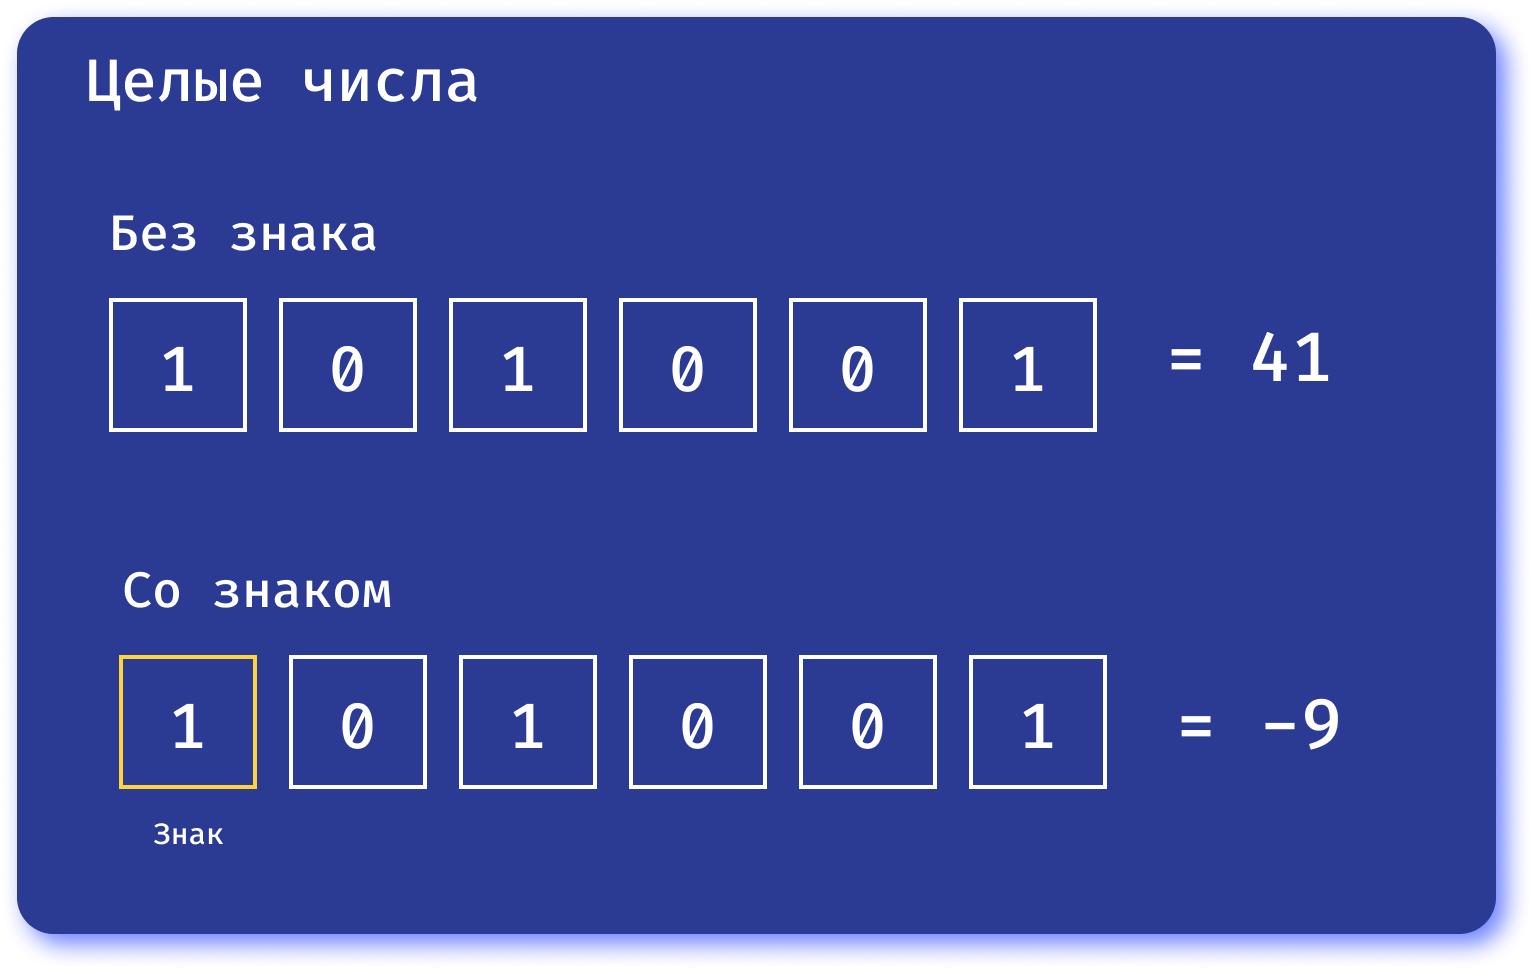

#### 2. Вещественные числа

Более сложный вопрос - как представить в памяти компьютера дробное число?

Первый вариант мало чем отличается от представления целых чисел. Мы представим число в виде десятичной дроби, а затем представим отдельно в виде двоичного числа её целую и дробную части. Этот способ плох тем, что требует заранее определить, сколько бит мы будем использовать под дробную и целую части, что приводит к неоптимальному использовании памяти. По этой причине, такой способ называется **вещественным число с фиксированной запятой**.

Альтернатива - использовать представление чисел **с плавающей запятой** (или как их еще называют - **с плавающей точкой**).

Числа с плавающей точкой состоят из трёх частей: мантиссы, экспоненты и знака. Мантисса представляет собой дробное число, экспонента определяет положение запятой в мантиссе, а знак указывает на знак числа.

Формула для представления числа с плавающей точкой выглядит следующим образом:

$$[(-1)^s \times m \times 2^e]$$

где $(s)$ - знак числа, $(m)$ - мантисса, $(e$) - экспонента.

Пример представления числа 6.25 в двоичной системе через мантиссу и экспоненту:

$$6.25_{10} = 110.01_{2} = 1.1001 \times 2^2$$

В данном примере знак числа равен 0 (положительное число), мантисса равна 1.1001, а экспонента равна 2.

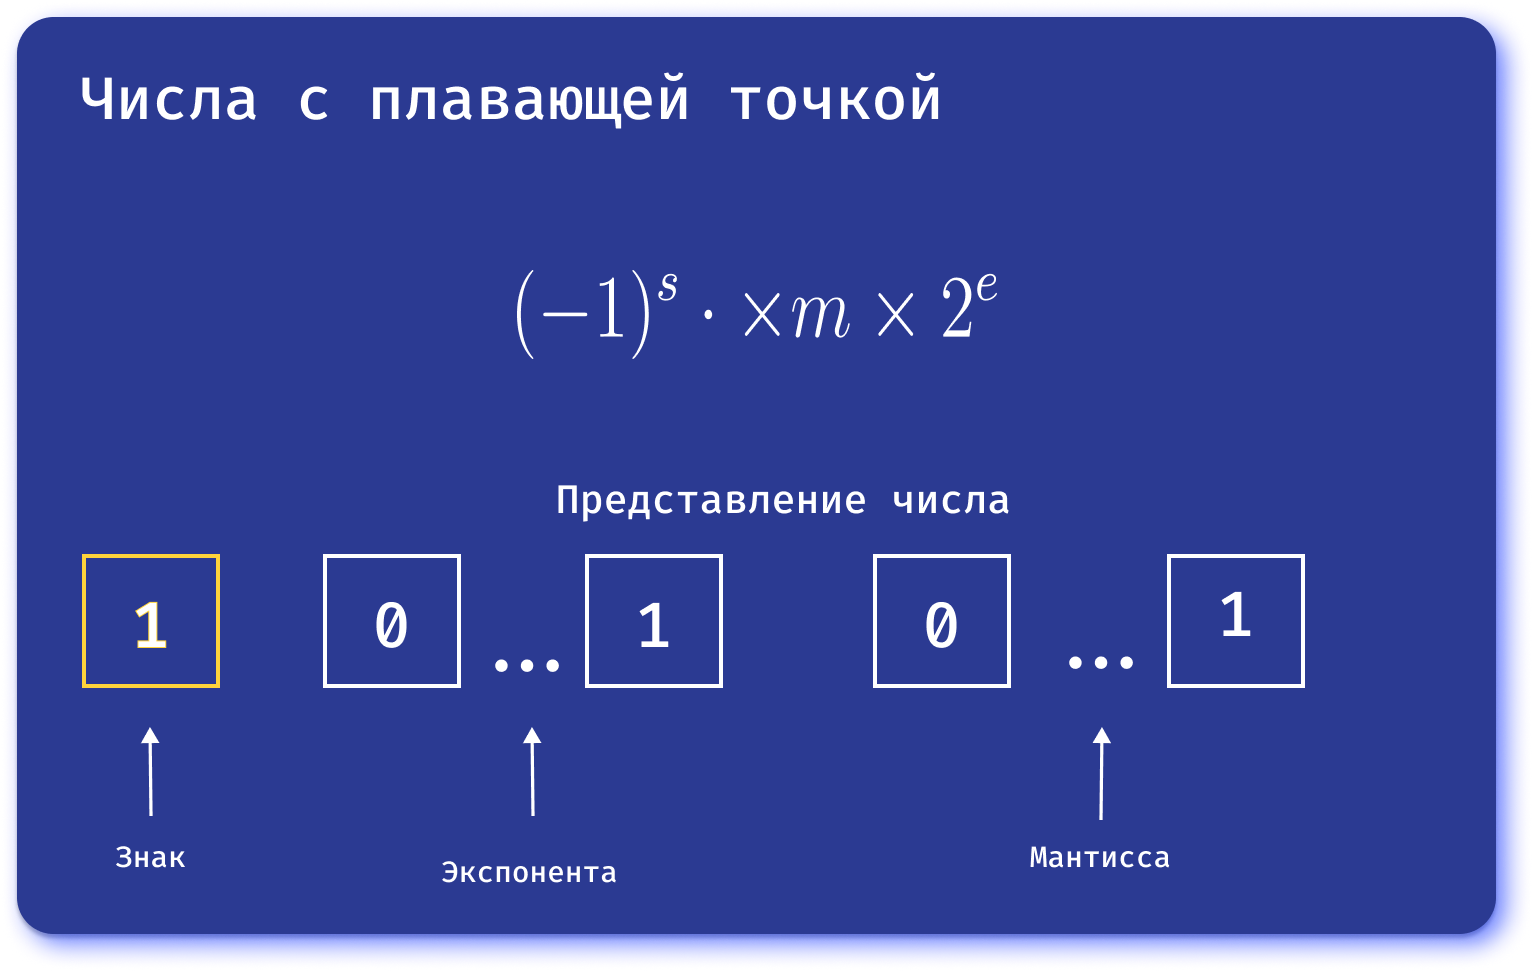

Представление чисел с плавающей точкой позволяет более эффективно использовать память компьютера, так как разряды мантиссы могут быть изменены в зависимости от величины числа. Это позволяет представлять как очень маленькие, так и очень большие числа с высокой точностью, что особенно важно при выполнении сложных математических операций. Кроме того, представление чисел с плавающей точкой позволяет более эффективно обрабатывать дробные числа и избегать потери точности при выполнении арифметических операций.

### Точность представления чисел

Ошибки представления чисел в памяти компьютера могут возникать из-за ограниченности количества бит, выделенных для хранения числа. Например, если мы используем 32-битное кодирование для хранения числа с плавающей точкой, то мы можем столкнуться с потерей точности при выполнении арифметических операций.

Это происходит из-за того, что числа с плавающей точкой представляются в виде мантиссы и экспоненты, что ограничивает точность представления. Например, число 0.1 в двоичной системе не может быть точно представлено в виде числа с плавающей точкой из-за бесконечной дроби.

В Python очень часто можно столкнуться с подобной проблемой. Для того чтобы проверить это, приведем очень простой пример:

In [ ]:
a = 0.1
b = 0.2
c = a + b

c

0.30000000000000004

В этом примере простейшая арифметическая операция формально дает ошибку, хоть и очень маленькую. Эта ошибка возникает именно из-за неточности представления чисел $0.1$ и $0.2$ в памяти.

Могут возникать и другие проблемы. Например, серьезная проблема переполнения. Она возникает, когда мы пытаемся представить слишком большое или слишком маленькое число которые не получается представить с учетом ограничений, накладываемых количеством бит, выделенных под тот или иной тип чисел. Если всё же требуется хранить такие числа, хранить их приходится специальным образом при помощи применения дополнительных алгоритмов и структур данных.

Существует понятие **машинного эпсилон**. Машинное эпсилон - это минимальное положительное число, которое можно представить в виде числа с плавающей точкой и прибавить к единице, не изменяя ее. Это значение зависит от точности представления чисел в памяти компьютера.

В `python` можно узнать значение машинного эпсилон, вызвав модуль `sys`:

In [ ]:
import sys

eps = sys.float_info.epsilon
print(eps)

2.220446049250313e-16


Проверим, что это число действительно является машинным эпсилон:

In [ ]:
import sys

eps = 1.0
while 1.0 + eps > 1.0:
    eps /= 2.0

if eps == sys.float_info.epsilon/2:
    print("Это действительно машинное эпсилон")
else:
    print("Это не машинное эпсилон")

Это действительно машинное эпсилон


В примере выше мы в цикле нашли такое минимальное число, которое мы можем прибавить к 1.0, чтобы его значение поменялось и сравнили с системным значением машинного эпсилон. Мы берем исходное значение `eps=1.0` и начинаем последовательно делить его на $2$ до тех пор, пока прибавление `eps` к единице дает эффект с точки зрения операции сравнения в питоне. Как только эффект пропадает, это значит, что мы нашли такое число, которое меньше машинного эпсилон.

## Выполнение программ

Теперь немного поговорим о том, как вообще выполняются программы, которые мы пишем.

Согласно основным принципам современных архитектур компьютеров, команды по преобразованию данных хранятся в памяти компьютера также, как и сами данные - в виде последовательностей двоичных чисел. Процессор умеет обрабатывать такие последовательности на аппаратном уровне. Такой код называется **машинным кодом**. Программы же представляют собой набор инструкций, которые выполняются компьютером для решения определенной задачи. Существует несколько уровней языков программирования, начиная от машинного кода, и заканчивая высокоуровневыми языками программирования, которые более понятны человеку.

Один из самых низкоуровневых языков программирования, на котором люди пишут код, называется **ассемблер**. Ассемблер - это язык программирования, который позволяет программистам писать инструкции на более понятном человеку виде, которые затем транслируются в машинный код.

Высокоуровневые языки программирования, такие как **Python, Java, C++**, позволяют программистам писать код на более абстрактном уровне, что делает его более понятным и удобным для работы. Весь код, написанный на языках программирования высокого уровня, **транслируется** в машинный код. Делается это, в свою очередь, также при помощи специальных программ - **компиляторов и интерпретаторов**.

В общем, компиляторы и интерпретаторы выполняют одну и ту же задачу - преобразование исходного кода программы в исполняемый код, однако используются они в разных ситуациях и обладают различными особенностями и преимуществами.

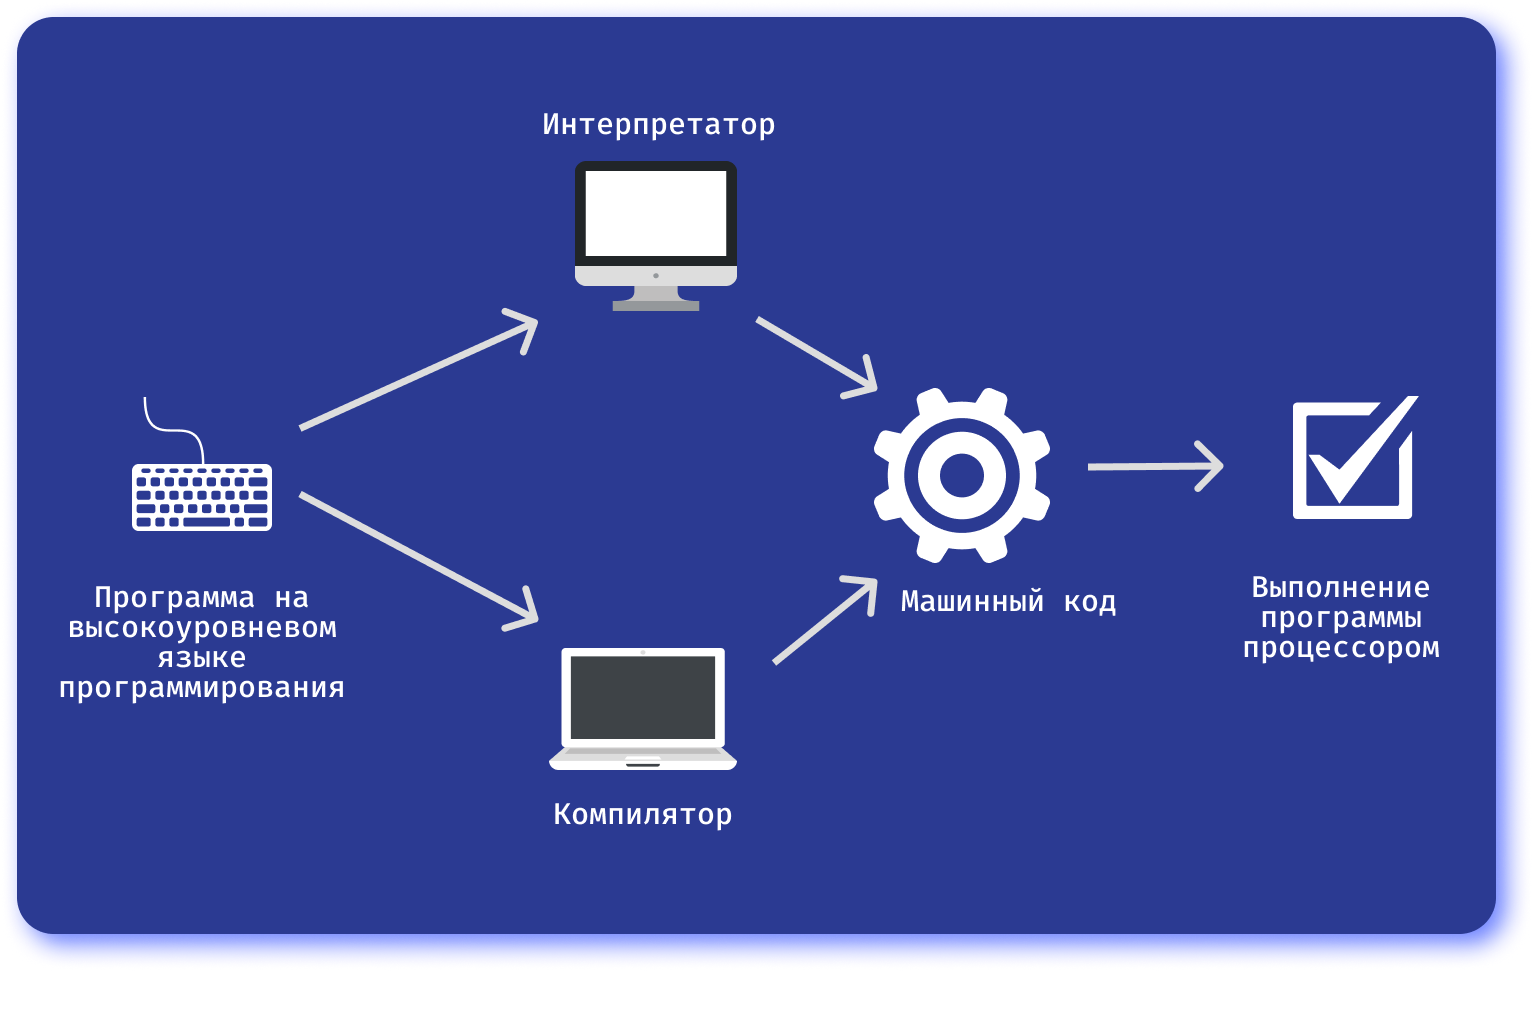

### Компиляторы

* **Компилятор** - это программа, которая преобразует весь исходный код программы в машинный код за один проход. То есть компилятор читает все исходные файлы кода, выполняет анализ и преобразует их в машинный код перед выполнением программы.

* Компиляторы обычно используются для создания автономных исполняемых файлов, которые могут быть запущены на компьютере без необходимости наличия исходного кода или самого компилятора.

* Преимущества компиляторов в том, что они обеспечивают быстрое исполнение программы, так как исходный код преобразуется в машинный код заранее.

Один из самых известных компилируемых языков программирования - **C++**.

### Интерпретаторы

* **Интерпретатор** - это программа, которая читает и анализирует исходный код программы построчно и выполняет его непосредственно во время работы программы.

* Интерпретаторы обычно используются для выполнения скриптов или для выполнения частей программы сразу после их написания. Также они широко используются в области интерактивной разработки и тестирования программ.

* Преимущества интерпретаторов в том, что они обеспечивают более высокую гибкость и простоту в разработке и тестировании программы, так как изменения в исходном коде могут быть немедленно выполнены и протестированы.

**Python** является интерпретируемым языком программирования.

### JIT-компиляция

**JIT-компиляция** (*Just-In-Time компиляция*) - это метод оптимизации выполнения программного кода, при котором код компилируется в машинный код непосредственно во время выполнения программы, а не заранее перед запуском. Это позволяет улучшить производительность программы за счет оптимизации кода.

В Python **JIT-компиляция** может применяться с помощью специализированных библиотек, таких как PyPy или Numba. PyPy - это реализация Python с JIT-компиляцией, которая может значительно ускорить выполнение Python-кода по сравнению с стандартным интерпретатором.

#### Numba

Один из основных фреймворков, используемых для оптимизации выполнения кода на **Python** - `Numba`. `Numba` представляет возможности по распараллеливанию вычислений, jit-компиляции и другие методы улучшения производительности. Давайте воспользуемся этим фреймворком и сравним скорость выполнения простых фрагментов кода на Python.

In [ ]:
!pip install numba

In [ ]:
import numpy as np
from numba import jit

Определим несложную численную функцию с циклом. Например, функцию суммирования всех элементов массива. Чтобы воспользоваться `jit`-компиляцией из `Numba` мы воспользуемся декоратором `@jit`:

In [ ]:
@jit(nopython=True)
def sum_array(arr):
    result = 0
    for i in arr:
        result += i
    return result

Чтобы проверить, сколько времени занимает выполнение кода, воспользуемся директивой `%timeit`:

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array(array_to_sum)

CPU times: user 239 ms, sys: 635 ms, total: 874 ms
Wall time: 872 ms


4999999950000000

А теперь сравним с производительностью аналогичной функции без применения `jit`-компиляции:

In [ ]:
def sum_array_slow(arr):
    result = 0
    for i in arr:
        result += i
    return result

In [ ]:
%%time

array_to_sum = np.arange(1000000)
sum_array_slow(array_to_sum)

CPU times: user 109 ms, sys: 0 ns, total: 109 ms
Wall time: 109 ms


499999500000

Здесь различие как-будто не очень чувствуется. А если увеличить число элементов в $100$ раз?

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array(array_to_sum)

CPU times: user 203 ms, sys: 202 ms, total: 406 ms
Wall time: 420 ms


4999999950000000

In [ ]:
%%time

array_to_sum = np.arange(10000000)
sum_array_slow(array_to_sum)

CPU times: user 1.09 s, sys: 13.2 ms, total: 1.1 s
Wall time: 1.11 s


49999995000000

А если в $1000$?

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array(array_to_sum)

CPU times: user 162 ms, sys: 153 ms, total: 316 ms
Wall time: 315 ms


4999999950000000

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array_slow(array_to_sum)

CPU times: user 11.8 s, sys: 165 ms, total: 12 s
Wall time: 12.1 s


4999999950000000

Разница между функциями состоит только в том, используем ли мы `jit`-кмпиляцию

### Особенности памяти в Python

Память в **Python** устроена на основе **ссылочной реализации**, что означает, что переменные в **Python** содержат не сами данные, а ссылки на объекты. Каждый объект в **Python** занимает определенное место в памяти, и переменная содержит ссылку на этот объект. Это позволяет использовать один объект в нескольких местах программы, просто создавая на него дополнительные ссылки.

**Динамическая типизация** в **Python** означает, что переменные не требуется объявлять с указанием их типа. Тип переменной определяется во время выполнения программы на основе данных, которые ей присваиваются. Это упрощает работу с переменными и позволяет уделять больше внимания разработке логики программы, а не заботиться о типах данных.

Для эффективного управления памятью в питоне существует, так называемый, **сборщик мусора**. Сборщик мусора в Python автоматически управляет памятью, освобождая объекты, которые больше не используются в программе. Это позволяет избежать утечек памяти и упрощает разработку программ, так как разработчику не нужно заботиться о выделении и освобождении памяти вручную.

Убедиться в том, что в питоне реализована именно ссылочная структура взаимодействия с памятью, очень просто. Создадим список `a`, а затем присвоим `a` новой переменной `b`. Обратившись к переменной `b`, изменим некоторый элемент списка.

In [ ]:
a = [1, 2, 3]
b = a
b[0] = 10

b

[10, 2, 3]

А теперь убедимся, что список `a` также изменился!

In [ ]:
a

[10, 2, 3]

Это происходит потому, что переменные `a` и `b` не содержат сам по себе объект, а лишь ссылку на его координаты в памяти компьютера. Меняя объект по адресу `b`, мы меняем его и по адресу `a`. **Об этом важно помнить при работе с серьезными программами!**

Переменные в питоне можно удалять, однако важно помнить, что удаляя переменную, мы удаляем только ссылку на объект, но не сам объект. Из-за этого может возникнуть ситуация, при которой объект всё еще находится в памяти и занимает место, но обратиться мы к нему не можем, потому что ссылка удалена. В идеале, сборщик мусора должен бороться с этой проблемой. Но в каких-то сложных ситуациях, может возникнуть необходимость очистить память самостоятельно. Для этого можно воспользоваться модулем `gc`.

In [ ]:
# Удалим переменную a
del a

In [ ]:
# Но все еще может обратиться к переменной b
b

[10, 2, 3]

In [ ]:
# К переменной a уже не получится
a

NameError: name 'a' is not defined

In [ ]:
# Удалим теперь и b тоже
del b

# Получим, так называемую, утечку памяти
# Вызовем модуль gc для её устранения
import gc
gc.collect()

3548

Если мы работаем с большими массивами данных, утечки могут быть существенными.

In [ ]:
import numpy as np

b = np.arange(500000000).tolist()
del b

In [ ]:
import gc
gc.collect()

106

## Параллельные вычисления

**Параллельное программирование** представляет собой методологию разработки программ, в которых задачи разделяются на более мелкие подзадачи, которые выполняются **параллельно**. Это позволяет значительно ускорить обработку данных. Для распараллеливания вычислений используются различные технологии -  многопоточность, распределенные вычисления, GPU и т.д.

Один из основных подходов к параллельному программированию - **многопоточность**. В случае разработки многопоточной программы, задачи делятся на независимые **потоки** выполнения, которые могут выполняться параллельно. Каждый поток имеет свою собственную область памяти и может работать независимо от других потоков. Этот подход обычно используется для распараллеливания вычислений на одном компьютере.

Использование **GPU** (видеокарты) - еще один способ распараллеливания вычислений. Графические процессоры обладают большим количеством ядер, что позволяет выполнять множество задач одновременно. Это особенно эффективно при обработке больших объемов данных, особенно - в области **ML** и **DL**.

Иногда для распределенных вычислений используется целая сеть компьютеров, где задачи могут быть выполнены на разных узлах сети. В этом случае данные передаются между узлами для обработки, что позволяет ускорить вычисления за счет параллельной обработки на нескольких устройствах.

Важно понимать, что не все задачи могут быть эффективно распараллелены. Некоторые задачи имеют зависимости между данными или требуют синхронизации потоков, что может привести к ухудшению производительности при параллельной обработке. Поэтому перед принятием решения о распараллеливании вычислений необходимо провести анализ задачи и определить ее пригодность для параллельного выполнения.

Но сами по себе параллельные вычисления являются очень мощным инструментом обработки больших объемов данных. Мы познакомимся с некоторыми библиотеками, позволяющими производить параллельные вычисления в **Python**.

### Распараллеливание циклов

Один из эффективных примеров применения распараллеливания - распараллеливание циклов. Существуют разные способы распараллелить цикл. Мы воспользууемся уже частично изученным нами декоратором `@jit` из `Numba`. если поставить значение аргумента `parallel=True`, то `Numba` постарается распараллелить выполнение внутренних циклов в функции. Посмотрим, как это улучшит производительность нашей функции.

In [ ]:
import numpy as np
from numba import jit

@jit(nopython=True, parallel=True)
def sum_array_paralell(arr):
    result = 0
    for i in range(len(arr)):
        result += arr[i]
    return result

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array_paralell(array_to_sum)

CPU times: user 176 ms, sys: 185 ms, total: 362 ms
Wall time: 393 ms


4999999950000000

Однако напрямую это сделать не удается. Давайте немного изменим цикл, чтобы все же добиться ускорения:

In [ ]:
@jit(nopython=True, parallel=True)
def parallel_sum(arr):
    return np.sum(arr)

In [ ]:
%%time

array_to_sum = np.arange(100000000)
parallel_sum(array_to_sum)

CPU times: user 806 ms, sys: 200 ms, total: 1.01 s
Wall time: 1.11 s


4999999950000000

Или так:

In [ ]:
@jit(nopython=True, parallel=True)
def sum_array_paralell(arr):
    N = 8
    result = 0
    for i in range(N):
      for j in range(i*int(len(arr)/N), (i+1)*int(len(arr)/N)):
        result += arr[i]
    return result

In [ ]:
%%time

array_to_sum = np.arange(100000000)
sum_array_paralell(array_to_sum)

CPU times: user 304 ms, sys: 212 ms, total: 516 ms
Wall time: 560 ms


/usr/local/lib/python3.10/dist-packages/numba/core/typed_passes.py:334: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "<ipython-input-25-5e09f639f4b2>", line 2:
@jit(nopython=True, parallel=True)
def sum_array_paralell(arr):
^

  warnings.warn(errors.NumbaPerformanceWarning(msg,


350000000

### Векторизация вычислений

Можно привести следующий пример векторизации вычислений: допустим, нам нужно выполнить определенную покомпонентную операцию с одним или несколькими массивами. Например, покомпонентно сложить элементы двух массивов. Первое желание - написать сложение через обычный цикл **for**. Немного подумав, мы поймём, что операция покомпонентного сложения допускает разделение на $N$ независимых операций сложения двух чисел, где $N$ - число компонент массивов. Каждую из них можно делать отдельно, а значит - имеет смысл их распараллелить и ускорить вычисления. Такой подход мы и будем называть векторизацией.

Использование внутренних функций `Numpy` всегда в приоритете, по сравнению с написанием аналогичных самостоятельно, поскольку векторизованные вычисления производятся быстрее и эффективнее, с применением, где это возможно, параллельных вычислений. Функции `Numpy` можно ускорять при помощи распараллеливания векторных вычислений.

Один из возможных вариантов - воспользоваться декоратором `@vectorize` из `Numba`.

Пусть, например, вы хотите написать функцию, позволяющую посчитать гипотенузы большого числа прямоугольных треугольников, катеты которых записаны в массивах `a` и `b``. Вы можете векторизовать вычисления следующим образом:

In [ ]:
from numba import vectorize, float64

def get_length(a, b):
    return np.sqrt(a**2 + b**2)

# векторизация
@vectorize([float64(float64, float64)])
def numba_get_length(a, b):
    return np.sqrt(a**2 + b**2)

В качестве аргумента здесь передается тип выходных и входных данных.

In [ ]:
a = np.array(np.random.sample(100000000), dtype=np.float64)
b = np.array(np.random.sample(100000000), dtype=np.float64)

In [ ]:
%%time

get_length(a, b)

CPU times: user 518 ms, sys: 478 ms, total: 997 ms
Wall time: 1 s


array([1.18516471, 0.71975626, 0.98879646, ..., 1.02464643, 0.78583354,
       0.95472061])

In [ ]:
%%time

numba_get_length(a, b)

CPU times: user 168 ms, sys: 157 ms, total: 325 ms
Wall time: 327 ms


array([1.18516471, 0.71975626, 0.98879646, ..., 1.02464643, 0.78583354,
       0.95472061])

## Заключение

Существует еще много инструментов распараллеливания, с которыми вы обязательно познакомитесь в процессе изучения **ML** и **DL**. При обучении нейронных сетей активно используется распаралелливание на видеокартах, а многие алгоритмы классического машинного обучения поддерживают возможность простого распараллеливания на **CPU**. В последнее время стаи популярны тензорные ядра **TPU**, позволяющие сверхэффективно распараллеливать матричные вычисления специально для обучения нейронных сетей.

Если вам интересно почитать больше о возможностях общих параллельных вычислений на питоне, рекомендую изучить библиотеки [multiprocessing](https://docs.python.org/3/library/multiprocessing.html) и [joblib](https://joblib.readthedocs.io/en/latest/parallel.html).